# Intertidal elevation from external sea level data

This notebook demonstrates how to run a DEA Intertidal Elevation workflow using **external sources of sea level data**, rather than tide modelling using global tide models via the [`eo-tides` Python package](https://geoscienceaustralia.github.io/eo-tides/).
This can be valuable for locations with access to high quality sea level measurements from tide gauge data, or access to custom high-resolution model data (e.g. local hydrodynamic modelling).

In this example, we load satellite data over **Roebuck Bay, Western Australia** from the [Microsoft Planetary Computer STAC API](https://planetarycomputer.microsoft.com/docs/quickstarts/reading-stac/), and obtain observed sea levels from the [GESLA Global Extreme Sea Level Analysis](https://gesla787883612.wordpress.com/) tide gauge dataset.

<!-- <div class="alert alert-info">
    
**Note:** For more information about afor DEA Intertidal using the `eo-tides` Python pacakge, refer to the [guide located here](https://geoscienceaustralia.github.io/eo-tides/setup/).

</div> -->

## Getting started
Set working directory to top level of repo to ensure links work correctly:

In [1]:
cd ..

/home/jovyan/Robbi/dea-intertidal


Install latest version of DEA Intertidal if required:

In [2]:
# %pip install -e . --quiet

Now **restart your Jupyter Notebook kernel.**

### Load packages

In [3]:
import os

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from dea_tools.dask import create_local_dask_cluster
from eo_tides.stac import load_ndwi_mpc
from eo_tides.validation import load_gauge_gesla

from intertidal.elevation import elevation
from intertidal.io import prepare_for_export

## Setup

### Set analysis parameters


In [4]:
# Location to analyse
study_area = "broome"
x = (122.15, 122.26)  # longitude bounds to load
y = (-18.24, -18.14)  # Latitude bounds to load
resolution = 20  # Spatial resolution used for analysis
cloud_cover = 10  # only load images with less than % cloud cover

# Time to analyse
start_date = "2019"  # Start date for analysis
end_date = "2021"  # End date for analysis

## Load satellite data

The first step in our analysis is to load some satellite data.
Here we use the [`load_ndwi_mpc` STAC satellite data loading function from `eo-tides`](https://geoscienceaustralia.github.io/eo-tides/api/#eo_tides.stac.load_ndwi_mpc). 
This function loads Landsat and Sentinel-2 data from Microsoft Planetary Computers, and convert this data to a remote sensing water index (Normalised Difference Water Index, or NDWI).

<div class="alert alert-info">
    
**Note:** You don't have to use the `load_ndwi_mpc` function to load data - data can be sourced from any optical satellite sensor that can be processed to NDWI (e.g. Sentinel-2, Landsat, Planet), and loaded from any source using STAC metadata (e.g. with the `odc-stac` Python package) or with Datacube (e.g. [Digital Earth Australia](https://knowledge.dea.ga.gov.au/notebooks/Beginners_guide/04_Loading_data/) or [Digital Earth Africa](https://docs.digitalearthafrica.org/en/latest/sandbox/notebooks/Beginners_guide/03_Loading_data.html)). The only requirement is to provide an `xarray.Dataset` satellite data timeseries that has been processed to include a water index variable called `ndwi`.

</div>



In [5]:
# Create local dask cluster to improve data load time
client = create_local_dask_cluster(return_client=True)

# Load data using odc-stac
satellite_ds = load_ndwi_mpc(
    lon=x,
    lat=y,
    time=(start_date, end_date),
    cloud_cover=cloud_cover,
)

# Load data into memory
satellite_ds.load()
satellite_ds

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/8787/status,
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/8787/status,Workers: 1
Total threads: 62,Total memory: 456.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44521,Workers: 0
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34105,Total threads: 62
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/41223/status,Memory: 456.00 GiB
Nanny: tcp://127.0.0.1:33261,


Found 288 STAC items for landsat-c2-l2
Found 275 STAC items for sentinel-2-l2a


/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


<xarray.Dataset> Size: 209MB
Dimensions:      (y: 372, x: 390, time: 360)
Coordinates:
  * y            (y) float64 3kB 7.994e+06 7.994e+06 ... 7.983e+06 7.983e+06
  * x            (x) float64 3kB 4.101e+05 4.101e+05 ... 4.217e+05 4.218e+05
    spatial_ref  int32 4B 32751
  * time         (time) datetime64[ns] 3kB 2019-01-09T01:50:40.565330 ... 202...
Data variables:
    ndwi         (time, y, x) float32 209MB 0.5319 0.5551 ... -0.4873 -0.5074

Plot some sample satellite NDWI timesteps.
We can see that these two images were taken at different tidal stages, with different areas of exposed intertidal terrain:

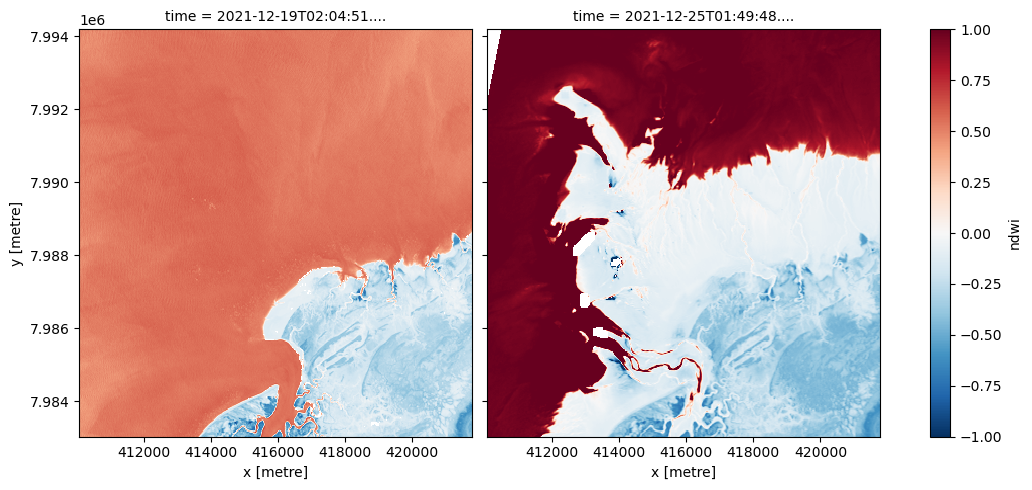

In [6]:
satellite_ds.ndwi.isel(time=[-3, -1]).plot.imshow(col="time", size=5)

## Load tide gauge data

For this example, we will use the [`load_gauge_gesla` function from `eo-tides`](https://geoscienceaustralia.github.io/eo-tides/api/#eo_tides.validation.load_gauge_gesla) to load a time series of observed sea levels from the [GESLA tide gauge](https://gesla787883612.wordpress.com/) nearest to our study area.

Using this function requires that you have access to GESLA data. 
You will need to download both **"GESLA-4 DATA"** (`GESLA4_ALL.zip`) and **"GESLA-4 CSV META-DATA FILE"** `GESLA4_ALL.csv`) from the [Downloads page of the GESLA website](https://gesla787883612.wordpress.com/downloads/), and save and extract these to a convenient location.

<div class="alert alert-info">
    
**Note:** You don't have to use the `load_gauge_gesla` function to load sea level data - data can be obtained from any source, provided it covers the epoch included in your time series and is of high enough frequency to associate each satellite image with a relevant sea level height measurement (at least hourly observations is recommended).

</div>

Loading GESLA gauges: 100%|██████████| 1/1 [00:00<00:00,  3.27it/s]


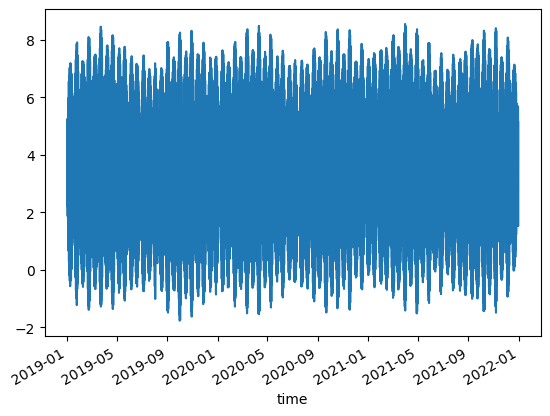

In [7]:
# Get x and y coordinates from centroid of satellite data
x, y = satellite_ds.odc.geobox.geographic_extent.centroid.coords[0]

# Load nearest GESLA tide gauge data
tide_data_df = load_gauge_gesla(
    x=x,
    y=y,
    time=(start_date, end_date),
    data_path="/gdata1/data/sea_level/GESLA4/GESLA4_ALL",
    metadata_path="/gdata1/data/sea_level/GESLA4/GESLA4_ALL.csv",
)

# Plot sea level time series
tide_data_df.droplevel("site_code").sea_level.plot();

The analysis requires that **external sea level data must have the same number of timesteps as our satellite data**.
We now need to filter our tide data to ensure that we have exactly one sea level measurement for every timestep in our satellite dataset.
The output should be a `pandas.Series` with a time index, and sea level values:

In [8]:
# Select nearest tide gauge observations to our satellite data,
# provided they are within 1 hour of each observation
tide_data_filtered = (
    tide_data_df.droplevel("site_code").reindex(satellite_ds.time, method="nearest", tolerance="1h").sea_level
)
tide_data_filtered

2019-01-09 01:50:40.565330    3.862
2019-01-09 02:04:49.024000    3.862
2019-01-10 01:49:22.057561    3.102
2019-02-02 01:55:27.669445    5.172
2019-02-08 02:04:49.024000    3.644
                              ...  
2021-12-09 02:04:41.024000    2.238
2021-12-16 01:55:34.164233    5.297
2021-12-19 02:04:51.024000    5.944
2021-12-24 01:55:59.758284    2.882
2021-12-25 01:49:48.266354    2.309
Name: sea_level, Length: 360, dtype: float64

We can plot our filtered data to see how it compares to our original sea level time series:

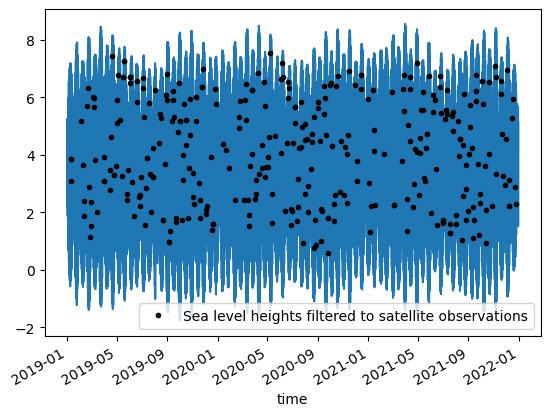

In [9]:
# Plot filtered tide heights over our original time series
tide_data_df.droplevel("site_code").sea_level.plot()
tide_data_filtered.plot(
    linestyle="none",
    marker="o",
    markersize=3,
    color="black",
    label="Sea level heights filtered to satellite observations",
    legend=True,
);

## Generate Intertidal elevation
We can now generate an intertidal elevation model by passing our external sea level data to the `intertidal.elevation.elevation` function using the `tide_data` parameter.
The function will use this external data instead of modelling tides.

<div class="alert alert-info">

**Note:** The output elevation model will be generated in the **height datum of the provided sea level data**.
We recommend making any datum corrections to the input tide data, rather than attempting to convert the output elevation model.

</div>


In [10]:
# Model elevation for each intertidal pixel
ds, _ = elevation(
    satellite_ds,
    tide_data=tide_data_filtered,
    windows_n=50,  # use high values (e.g. 100) to produce more detail
)
ds

2025-10-08 01:11:23 INFO Processing: Using provided tide heights
2025-10-08 01:11:23 INFO Processing: Flattening satellite data array and filtering to intertidal candidate pixels
2025-10-08 01:11:26 INFO Processing: Running per-pixel rolling median


Reducing analysed pixels from 145080 to 69001 (47.56%)


  0%|          | 0/55 [00:00<?, ?it/s]

2025-10-08 01:12:18 INFO Processing: Modelling intertidal elevation


Applying tidal interval interpolation to 200 intervals
Applying rolling mean smoothing with radius 20


2025-10-08 01:12:19 INFO Processing: Modelling intertidal uncertainty
2025-10-08 01:12:20 INFO Processing: Unflattening data back to its original spatial dimensions
2025-10-08 01:12:20 INFO Processing: Cleaning inaccurate upper intertidal pixels
2025-10-08 01:12:20 INFO Processing: Successfully completed intertidal elevation modelling


<xarray.Dataset> Size: 6MB
Dimensions:                (y: 372, x: 390)
Coordinates:
  * y                      (y) float64 3kB 7.994e+06 7.994e+06 ... 7.983e+06
  * x                      (x) float64 3kB 4.101e+05 4.101e+05 ... 4.218e+05
    spatial_ref            int32 4B 32751
Data variables:
    elevation              (y, x) float64 1MB nan nan nan nan ... nan nan nan
    elevation_uncertainty  (y, x) float64 1MB nan nan nan nan ... nan nan nan
    qa_ndwi_freq           (y, x) float64 1MB 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0
    qa_ndwi_corr           (y, x) float64 1MB nan nan nan nan ... nan nan nan
    qa_count_clear         (y, x) int64 1MB 259 256 256 255 ... 294 295 294 293

### Plot outputs

We can now inspect the outputs of our intertidal elevation modelling.
This includes elevation data (measured in metres relative to Mean Sea Level), elevation uncertainty (metres), the correlation between inundation patterns in each pixel and the modelled tide data, and the inundation frequency of each pixel.

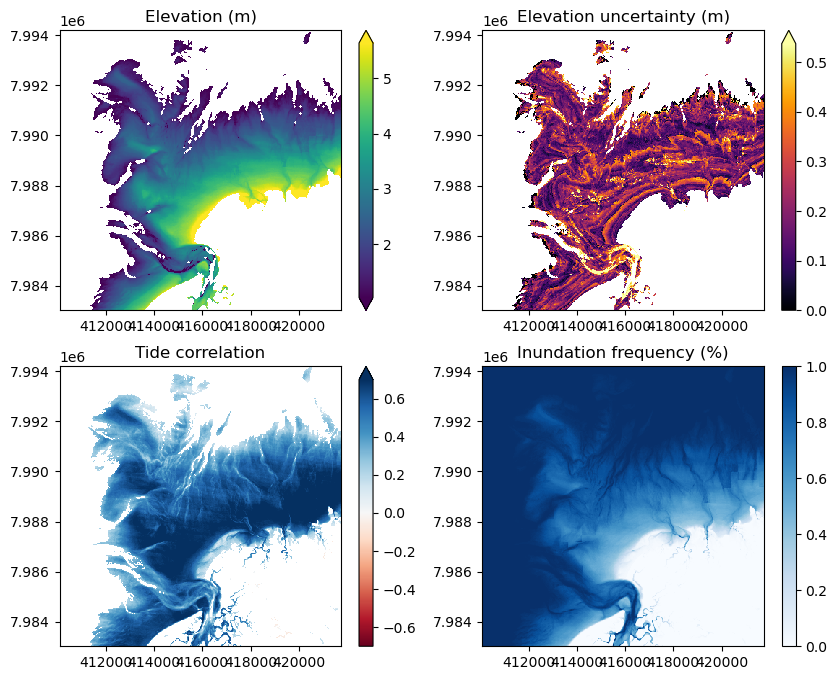

In [11]:
fix, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

ds.elevation.plot.imshow(cmap="viridis", robust=True, ax=axes[0], label=False, add_labels=False)
axes[0].set_title("Elevation (m)")
ds.elevation_uncertainty.plot.imshow(cmap="inferno", robust=True, ax=axes[1], label=False, add_labels=False)
axes[1].set_title("Elevation uncertainty (m)")
ds.qa_ndwi_corr.plot.imshow(cmap="RdBu", vmin=-0.7, vmax=0.7, ax=axes[2], label=False, add_labels=False)
axes[2].set_title("Tide correlation")
ds.qa_ndwi_freq.plot.imshow(cmap="Blues", vmin=0, vmax=1, ax=axes[3], label=False, add_labels=False)
axes[3].set_title("Inundation frequency (%)");

View the data on an interactive map for a closer look:

In [12]:
ds.elevation.odc.explore(robust=True)

## Export outputs

We can now export our outputs to file as GeoTIFF rasters:

In [13]:
# Create output folder if it doesn't exist
output_dir = f"data/interim/{study_area}/{start_date}-{end_date}"
os.makedirs(output_dir, exist_ok=True)

# Prepare data for export
ds["qa_ndwi_freq"] *= 100  # Convert frequency to %

# Prepare for export by correctly setting nodata and dtypes, then
# export to file
ds_prepared = prepare_for_export(ds, output_location=output_dir)

### Close Dask client

In [14]:
client.close()